# 1.0 import libraries


In [49]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)


In [50]:
train_df=pd.read_csv('diabetes_train.csv')
val_df=pd.read_csv('diabetes_val.csv')
test_df=pd.read_csv('diabetes_test.csv')

X_train=train_df.drop(columns=['Outcome']).values.astype(np.float32)
y_train = train_df['Outcome'].values.astype(np.float32)

X_val=val_df.drop(columns=['Outcome']).values.astype(np.float32)
y_val=val_df['Outcome'].values.astype(np.float32)

X_test=test_df.drop(columns=['Outcome']).values.astype(np.float32)
y_test=test_df['Outcome'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"num of features: {X_train.shape[1]}")

Train: (537, 14)
Val: (115, 14)
Test: (116, 14)
num of features: 14


In [51]:
with open ('diabetes_metadata.json') as f :
    metadata = json.load(f)
feature_cols = metadata['feature_cols']
train_medians= metadata['train_medians']
scaler_mean= np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"loaded metadata for {len(feature_cols)} features")

scaler_scale



loaded metadata for 14 features


array([3.3820171e+00, 2.9510159e+01, 1.2327506e+01, 9.1778965e+00,
       8.1450020e+01, 6.6842527e+00, 3.2427591e-01, 1.1811565e+01,
       1.3876493e+03, 4.3319400e+02, 4.3056646e-01, 4.8798811e-01,
       4.8535880e-01, 4.5137453e-01], dtype=float32)

In [52]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    #block1
    x=keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.3)(x)


    #block 2
    x=keras.layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.3)(x)

     #block 3
    x=keras.layers.Dense(32)(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.2)(x)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)

    return keras.Model(inputs, outputs, name='DiabetesANN')
    
model = build_ann(X_train.shape[1])
model.summary()



Model: "DiabetesANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [53]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)
                          


In [54]:
callbacks=[
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_diabetes.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = model.fit(
    X_train, y_train, epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run:  {len(history.history['loss'])}")
print(f"Best val AUC:  {max(history.history['val_auc']):.4f}")


Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4972 - auc: 0.5868 - loss: 0.7764 - precision: 0.3772 - recall: 0.6702 - val_accuracy: 0.6435 - val_auc: 0.8087 - val_loss: 0.6640 - val_precision: 0.4925 - val_recall: 0.8250 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6797 - auc: 0.7379 - loss: 0.6017 - precision: 0.5370 - recall: 0.6170 - val_accuracy: 0.7478 - val_auc: 0.8375 - val_loss: 0.5922 - val_precision: 0.6170 - val_recall: 0.7250 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7542 - auc: 0.7860 - loss: 0.5452 - precision: 0.6573 - recall: 0.6223 - val_accuracy: 0.7565 - val_auc: 0.8470 - val_loss: 0.5454 - val_precision: 0.6364 - val_recall: 0.7000 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7579 - auc: 0.7968 - loss: 0.5338 - precision: 0.6768 - recall: 0.5904 - val_accuracy: 0.7478 - val_auc: 0.8513 - val_loss: 

<function matplotlib.pyplot.show(close=None, block=None)>

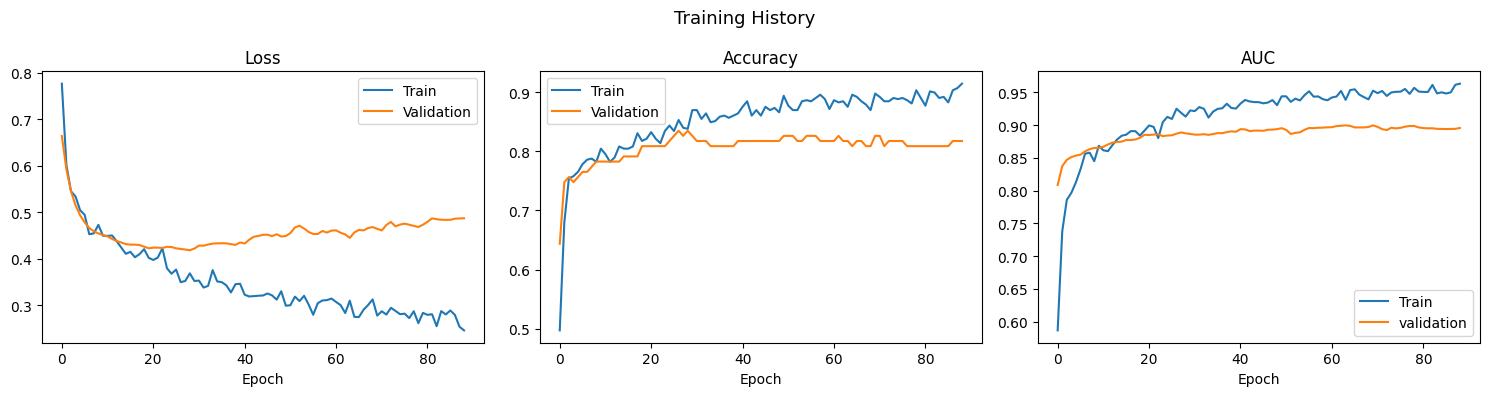

In [55]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='validation')
axes[2].set_xlabel('Epoch')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png' , dpi=150, bbox_inches='tight')
plt.show

In [56]:
model.load_weights('best_diabetes.keras')
test_results=model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print (f"{name:<12}: {value:.4f}")

loss        : 0.4069
compile_metrics: 0.8534


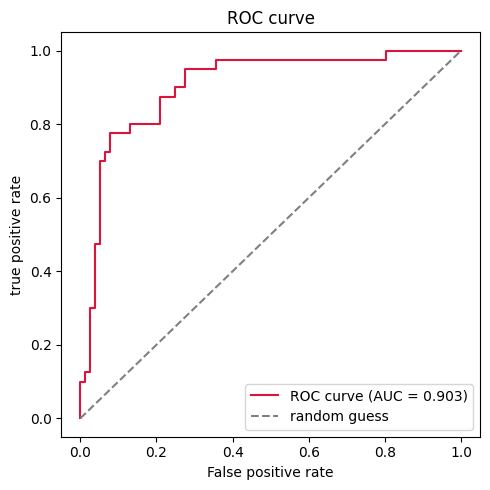

ROC-AUC : 0.9026


In [57]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize = (5,5))
plt.plot(fpr,tpr, color='crimson', label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], color = 'gray', linestyle='--', label='random guess')
plt.xlabel("False positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC : {auc_score:.4f}")

              precision    recall  f1-score   support

 NO Diabetes       0.88      0.89      0.89        76
    Diabetes       0.79      0.78      0.78        40

    accuracy                           0.85       116
   macro avg       0.84      0.83      0.84       116
weighted avg       0.85      0.85      0.85       116



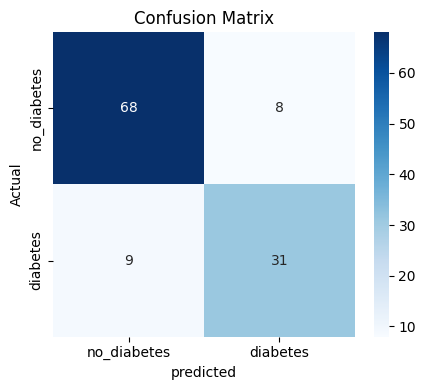

In [58]:
y_pred = (y_prob >= 0.5).astype(int)
import seaborn as sns
print(classification_report(y_test, y_pred, target_names=['NO Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d' , cmap='Blues',
            xticklabels=['no_diabetes', 'diabetes'],
            yticklabels=['no_diabetes', 'diabetes'])
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


           

In [59]:
model.save('diabetes_ann.keras')

with open ('diabetes_inference_kit.pk1', 'wb') as f:
    pickle.dump({
        'scaler_mean':scaler_mean,
        'scaler_scale': scaler_scale,
        'feature_cols': feature_cols,
        'train_median': train_medians,
    }, f)
print("saved diabetes_ann.keras")
print("saved diabetes_inference_kit.pkl")

saved diabetes_ann.keras
saved diabetes_inference_kit.pkl


In [62]:
def predict_patient(patient, model, feature_cols, scaler_mean, scaler_scale):
     patient = patient.copy()
      # Add the same extra features we created during data preparation
    
     patient['Glucose_x_BMI'] = patient['Glucose'] * patient['BMI']
     patient['Age_x_BMI'] = patient['Age'] * patient['BMI']
     patient['impaired_glucose'] = float(patient['Glucose'] >= 100)
     patient['diabetic_glucose'] = float(patient['Glucose'] >= 126)
     patient['is_obese'] = float(patient['BMI'] >= 30)
     patient['older_patient'] = float(patient['Age'] >= 40)
    
    # Put the features in the exact same order the model expects\n",
     row = np.array([patient[col] for col in feature_cols], dtype=np.float32)

    # Scale by hand: same formula the training data went through\n",
     row_scaled = (row - scaler_mean) / scaler_scale
     row_scaled = row_scaled.reshape(1, -1)
     probability = model.predict(row_scaled, verbose=0)[0][0]
     prediction = 'Diabetes' if probability >= 0.5 else 'No Diabetes'
     print(f"Probability of diabetes: {probability:.1%}")
     print(f"Prediction: {prediction}")
   
  

In [63]:
patient_1 = {8
    'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72, 'SkinThickness': 35,
    'Insulin': 0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50,
}   
print("Patient 1 (actual: Diabetes)")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)
    
print()
    
patient_2 = {
    'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66, 'SkinThickness': 29,
    'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 31,
}
print("Patient 2 (actual: No Diabetes)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)

Patient 1 (actual: Diabetes)
Probability of diabetes: 0.1%
Prediction: No Diabetes

Patient 2 (actual: No Diabetes)
Probability of diabetes: 0.0%
Prediction: No Diabetes
